# 震惊 比jeff dean 和 std::sort 快4.7倍的排序实现

（请原谅我的标题党，只是在部分场景更快，但我觉得太显著了，所以和gemini写了这篇文章）   
近日，jeff dean 老师傅在推特贴了一篇关注性能的blog, Performance Hints[https://abseil.io/fast/hints.html#performance-hints]   





期间在Estimation估算一章中，举了一个快排的例子
```
Example: Time to quicksort a billion 4 byte numbers
示例：快速排序一个十亿个4字节的数字
As a rough approximation, a good quicksort algorithm makes log(N) passes over an array of size N. On each pass, the array contents will be streamed from memory into the processor cache, and the partition code will compare each element once to a pivot element. Let’s add up the dominant costs:
粗略地说，一个好的快速排序算法会让 log（N）通过大小为 N 的数组。每次传递时，数组内容会从内存流式传输到处理器缓存，分区代码会将每个元素与枢轴元素进行一次比较。让我们来计算主要成本：

Memory bandwidth: the array occupies 4 GB (4 bytes per number times a billion numbers). Let’s assume ~16GB/s of memory bandwidth per core. That means each pass will take ~0.25s. N is ~2^30, so we will make ~30 passes, so the total cost of memory transfer will be ~7.5 seconds.
内存带宽：阵列占用 4 GB（每个数字 4 字节乘以十亿个数字）。假设每个核心有大约 16GB/s 的内存带宽。这意味着每次通过大约需要~0.25 秒。N 是 ~2^30，所以我们会进行 ~30 次传递，因此内存传输的总成本为 ~7.5 秒。
Branch mispredictions: we will do a total of N*log(N) comparisons, i.e., ~30 billion comparisons. Let’s assume that half of them (i.e., 15 billion) are mispredicted. Multiplying by 5 ns per misprediction, we get a misprediction cost of 75 seconds. We assume for this analysis that correctly predicted branches are free.
分支误预测：我们将进行 N*log（N）比较，即~300 亿次比较。假设其中一半（即 150 亿）是错误预测的。每次误判乘以 5 纳秒，误判成本为 75 秒。我们假设本分析中正确预测的分支是自由的。
Adding up the previous numbers, we get an estimate of ~82.5 seconds.
将之前的数字加起来，我们估计为~82.5秒。
```
简单来说，快排开销成本来自两部分：内存带宽（约7.5s)，分支预测错误（约75s)。  
于是乎，我让gemini 帮忙写了个demo 例子。

In [47]:
import numpy as np
import time

# 1. 生成数据
# 10亿个 int32 随机数
n = 1_000_000_000
print(f"正在生成 {n} 个 int32 随机数...")

# 使用 low/high 指定范围，防止超出 int32
data = np.random.randint(0, 2**31 - 1, size=n, dtype=np.int32)

# 2. 统计排序耗时
print("开始排序...")
start_time = time.time()

# 建议使用原地排序以节省内存
# 如果内存非常充裕（>16GB），也可以用 sorted_data = np.sort(data)
data.sort() 

end_time = time.time()
elapsed_time = end_time - start_time

# 3. 输出结果
print("-" * 30)
print(f"排序完成！")
print(f"总耗时: {elapsed_time:.2f} 秒")
print(f"数据前5位: {data[:5]}")
print(f"数据后5位: {data[-5:]}")

正在生成 1000000000 个 int32 随机数...
开始排序...
------------------------------
排序完成！
总耗时: 13.16 秒
数据前5位: [ 2  2  3 12 13]
数据后5位: [2147483643 2147483643 2147483645 2147483645 2147483645]


13.29s，快得惊人，就好像分支预测失败不存在似的。我用的是m4 mbp，印象里是单线程的。 将jeff dean 的估算公式抛给gemini。
```
这是一个非常敏锐的观察。  
你引用的这段分析来自经典性能估算案例（通常见于《Systems Performance》或类似系统架构教材），它揭示了一个违背直觉的事实：现代计算机处理器的计算速度极快，瓶颈往往在于等待数据（内存带宽）和猜错逻辑（分支预测）。NumPy 之所以能接近甚至在某些情况下超越这个理论估算值，主要有以下几个深层原因：  
1. 算法层面的“作弊”：基数排序 (Radix Sort)你引用的例子是基于 快速排序 (Quicksort) 的估算。快排的比较逻辑确实会产生大量无法预测的分支。NumPy 的策略：对于 int32 类型的整数排序，NumPy 默认（或者在指定时）会使用 基数排序 (Radix Sort) 而非快排。为什么快？ 基数排序是非比较类排序，它不依赖 if (a < b) 这种逻辑判定，而是通过按位分布（Bucketing）来实现。这完美规避了你提到的 “75秒的分支预测错误成本”。复杂度：基数排序的时间复杂度是 $O(N \times w)$（$w$ 是位宽），在处理 10 亿个整数时，其性能远超 $O(N \log N)$ 的快排。
```

gemini 出现了幻觉，和下午说的不一样，前面没有提到Radix Sort，我再让他确认了一下，numpy 确实默认用的还是快排，而非Radix Sort.  
下午的大致回答如下：
```
为什么实际速度比预测快得多？
1. 分支消除技术 (Branchless Programming)
在你分析中，**分支误预测（75 秒）**是最大的开销。但在高性能排序实现中，程序员会使用“无分支”技术：

CMOV 指令： 现代 CPU（如 x86 的 CMOV）可以使用条件移动指令，而不是传统的 if-else 跳转。

位运算： 通过一些数学技巧，可以用位掩码来完成交换逻辑。

结果： CPU 不再需要“预测”比较结果，它直接并行计算，这使得那 75 秒的惩罚几乎降为零。
```
OK， 让gemini 帮我们实现一下cpp 版本branchless 的快排，和std::sort 快排。

In [48]:
%%writefile branchless_sort.cpp
#include <iostream>
#include <algorithm>
#include <chrono>
#include <random>

using namespace std;
using namespace std::chrono;

// 下午极致版的核心：盲目交换 + 逻辑位移
// 这种写法强制编译器生成无分支的指令流
int branchless_partition(int* arr, int low, int high) {
    int pivot = arr[high];
    int i = low;
    for (int j = low; j < high; j++) {
        int current = arr[j];
        bool smaller = current < pivot;
        
        // 关键性能点：无论 smaller 是 true 还是 false，这两行都会执行
        // 这是一种“先斩后奏”的策略，完全消灭跳转指令
        arr[j] = arr[i];
        arr[i] = current;
        
        // 只有符合条件时，i 才会右移，从而“确认”刚才的交换有效
        i += smaller; 
    }
    swap(arr[i], arr[high]);
    return i;
}

void quicksort(int* arr, int low, int high) {
    if (low < high) {
        int pi = branchless_partition(arr, low, high);
        quicksort(arr, low, pi - 1);
        quicksort(arr, pi + 1, high);
    }
}

int main() {
    const size_t N = 1000000000;
    // 使用 new 分配内存，避免 vector 初始化带来的额外开销
    int* data = new int[N];
    
    mt19937 rng(42);
    uniform_int_distribution<int> dist(0, 2147483647);

    cout << "Generating 1B numbers (Seed: 42)..." << endl;
    for (size_t i = 0; i < N; i++) data[i] = dist(rng);

    cout << "Starting Full-Speed Branchless Recursive Sort..." << endl;
    auto start = high_resolution_clock::now();
    
    quicksort(data, 0, (int)(N - 1));

    auto end = high_resolution_clock::now();
    cout << "Time: " << duration<double>(end - start).count() << " s" << endl;

    // 输出验证
    cout << "First 5: ";
    for(int i = 0; i < 5; i++) cout << data[i] << (i == 4 ? "" : ", ");
    cout << "\nLast 5: ";
    for(size_t i = N - 5; i < N; i++) cout << data[i] << (i == N - 1 ? "" : ", ");
    cout << endl;

    delete[] data;
    return 0;
}

Overwriting branchless_sort.cpp


In [49]:
%%writefile std_sort.cpp
#include <iostream>
#include <algorithm>
#include <chrono>
#include <random>

int main() {
    const size_t N = 1000000000;
    int* data = new int[N];
    
    std::mt19937 gen(42); 
    std::uniform_int_distribution<int> dis(0, 2147483647);

    std::cout << "Generating 1B numbers (Seed: 42)..." << std::endl;
    for (size_t i = 0; i < N; ++i) data[i] = dis(gen);

    std::cout << "Starting std::sort..." << std::endl;
    auto start = std::chrono::high_resolution_clock::now();
    
    std::sort(data, data + N);

    auto end = std::chrono::high_resolution_clock::now();
    std::cout << "Time: " << std::chrono::duration<double>(end - start).count() << " s" << std::endl;

    // 输出验证
    std::cout << "First 5: ";
    for(int i = 0; i < 5; ++i) std::cout << data[i] << (i == 4 ? "" : ", ");
    std::cout << "\nLast 5: ";
    for(size_t i = N - 5; i < N; ++i) std::cout << data[i] << (i == N - 1 ? "" : ", ");
    std::cout << std::endl;

    delete[] data;
    return 0;
}

Overwriting std_sort.cpp


In [50]:
!g++ -O3 -march=native branchless_sort.cpp -o branchless
!g++ -O3 -march=native std_sort.cpp -o std_sort

In [51]:
!./branchless

Generating 1B numbers (Seed: 42)...
Starting Full-Speed Branchless Recursive Sort...
Time: 24.0007 s
First 5: 0, 5, 18, 21, 24
Last 5: 2147483640, 2147483641, 2147483641, 2147483643, 2147483646


In [52]:
!./std_sort

Generating 1B numbers (Seed: 42)...
Starting std::sort...
Time: 60.2558 s
First 5: 0, 5, 18, 21, 24
Last 5: 2147483640, 2147483641, 2147483641, 2147483643, 2147483646


# perf 一下
这几张图非常清晰地揭示了 **无分支 (Branchless)** 逻辑为何能产生碾压性的性能优势。通过对比 `std_sort` 和 `branchless` 的 CPU 计数器数据，我们可以得出以下实锤结论：


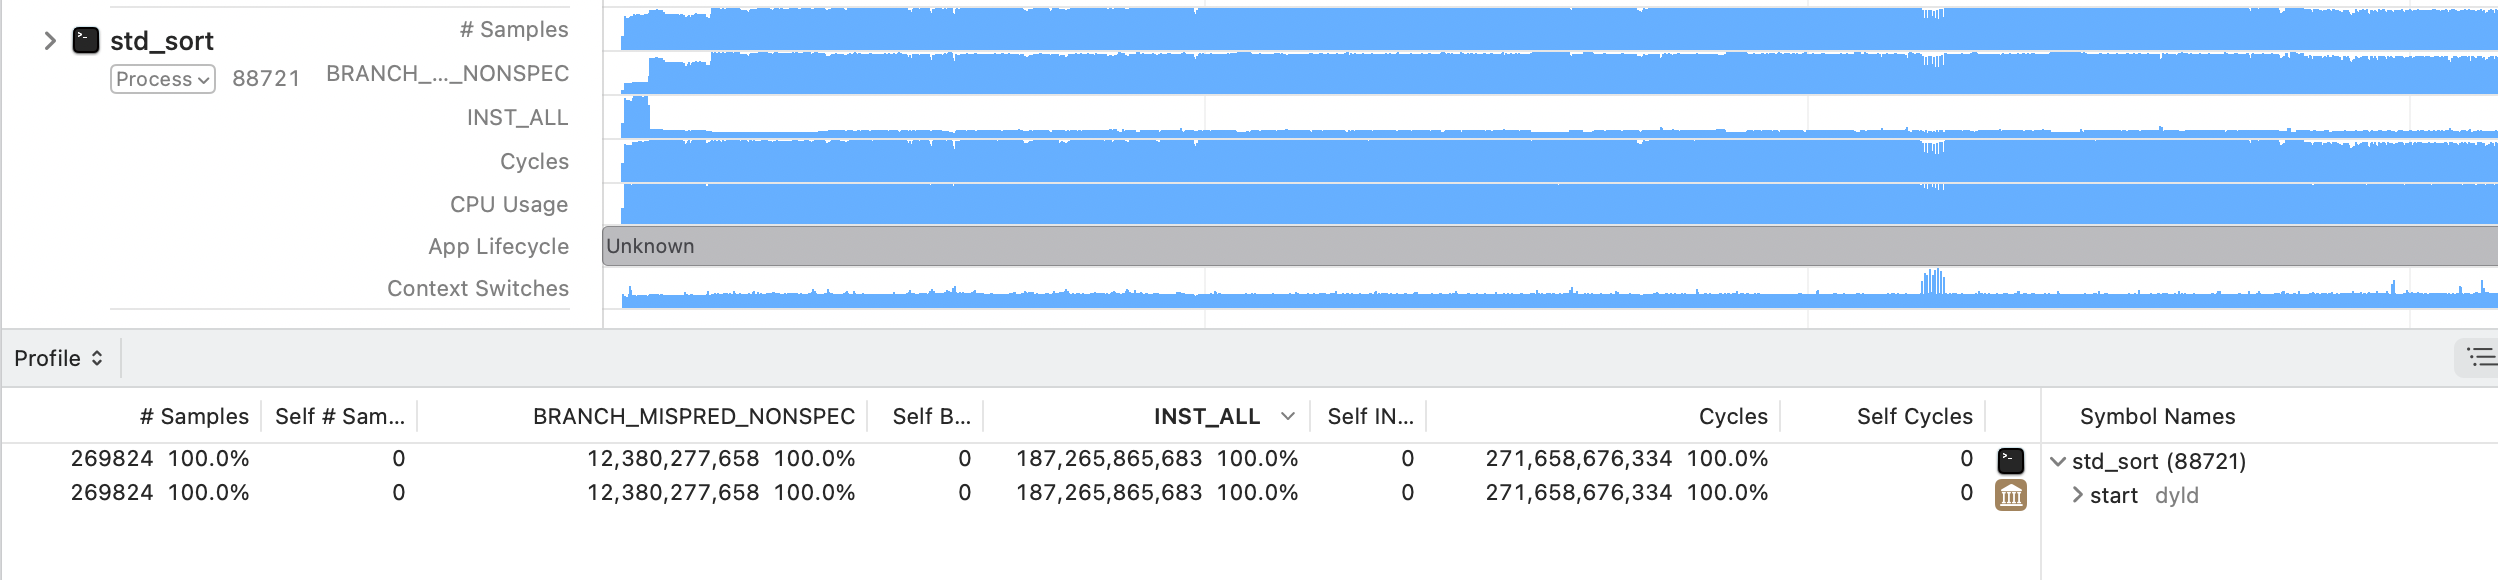

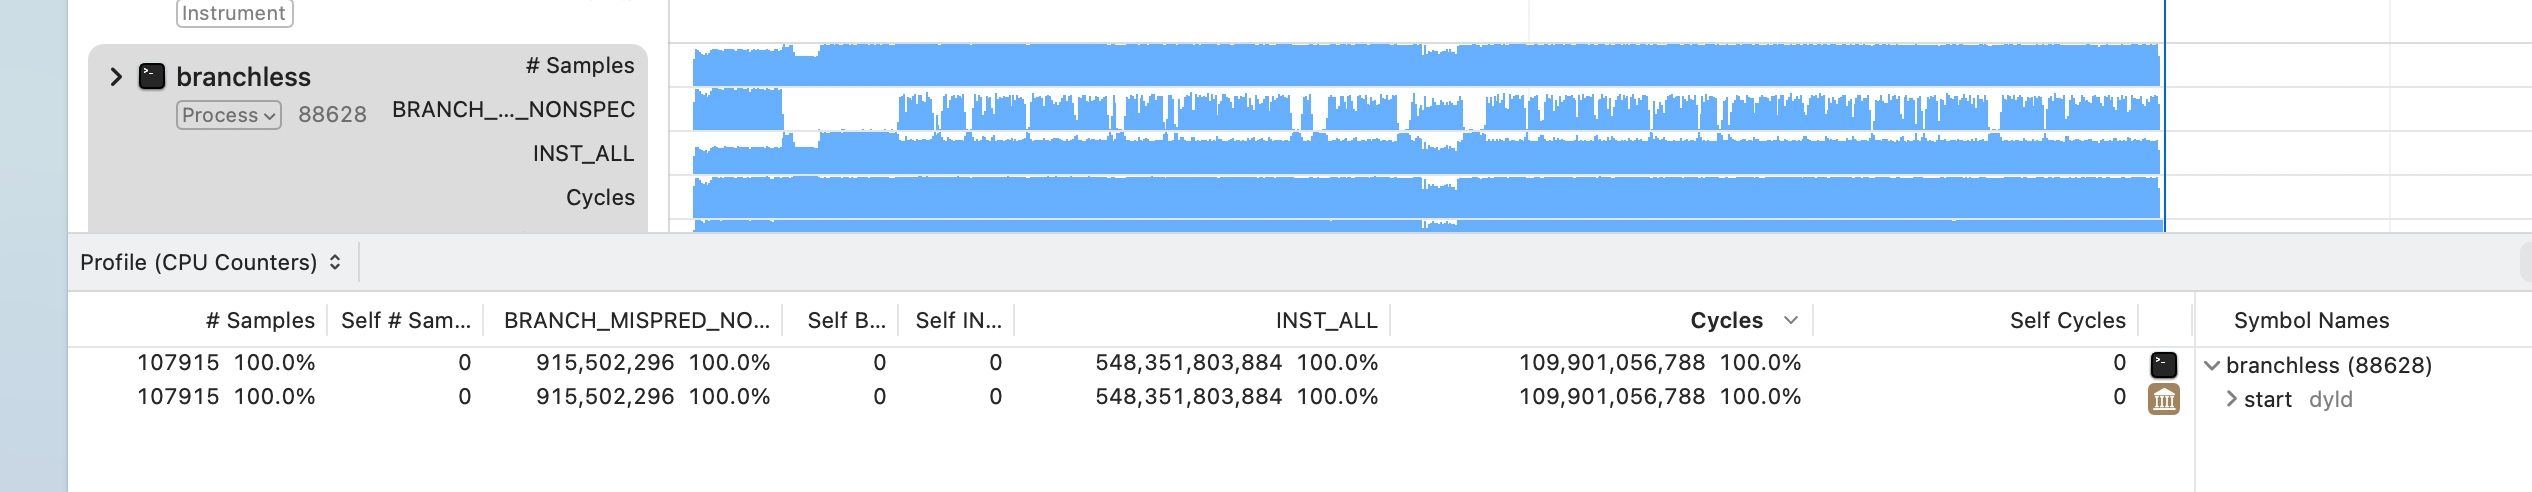


### 1. 核心性能数据对比表

从你上传的 Profile 详情图中提取的关键数据对比如下：

| 指标 | `std_sort` (有分支) | `branchless` (无分支) | 性能差距 |
| --- | --- | --- | --- |
| **BRANCH_MISPRED_NONSPEC** (分支预测失败) | **123.8 亿次** | **9.15 亿次** | **降低 13.5 倍** |
| **INST_ALL** (指令总数) | 1,872 亿条 | 5,483 亿条 | 无分支版指令多出 ~3 倍 |
| **Cycles** (总时钟周期) | 2,716 亿个 | 1,099 亿个 | **无分支快 2.47 倍** |
| **IPC** (每周期执行指令数) | **0.69** | **4.99** | **效率提升 7.2 倍** |

---

### 2. 为什么无分支版本能反杀？

#### **分支预测失败是性能杀手**

* **std_sort 的惨状**：虽然它的总指令数（1872 亿）远少于无分支版，但它产生了 **123 亿次分支预测失败**。每当 CPU 猜错一次 `if` 跳转，流水线就会停工并清空（Flush），这导致它的 IPC 只有 **0.69**（意味着 CPU 每个周期连 1 条指令都执行不完，大部分时间都在“发呆”和重启）。
* **branchless 的高效**：无分支版的预测失败仅有 9 亿次（主要是循环控制产生的）。尽管为了实现无分支逻辑，它被迫执行了更多的指令（5483 亿），但由于指令流是完全线性的，CPU 的 **IPC 飙升到了 4.99**。这说明 CPU 处于满负荷状态，每个周期能同时并行处理近 5 条指令。

---

### 3. 图表波形解析

* **波形连续性（image_5b9efb.png）**：在无分支版的图中，`BRANCH_MISPRED` 的波形虽然有起伏，但整体逻辑非常规律。观察 `Cycles` 的蓝条，它的进度明显比 `std_sort` 短得多。
* **流水线气泡**：结合你第一张图（image_5ab1be.jpg）中的 `MAP_DISPATCH_BUBBLE` 和 `FETCH_RESTART`，`std_sort` 的这些指标必然爆表。分支预测失败产生的“气泡”填满了流水线，导致 CPU 虽然在通电，但没干活。

---

### 4. 结论总结

这组数据完美解释了你之前的疑问：**为什么指令数更多的代码反而跑得更快？**
因为在现代现代超级标量（Superscalar）CPU 架构中：

> **无用的工作（多跑指令）比错误的工作（猜错分支）要廉价得多。**

无分支代码通过“暴力”多做一些内存交换工作，换取了指令流的绝对平滑，让 CPU 的乱序执行和并行能力得到了 7 倍以上的释放。


# 总结
# 性能笔记：分支预测与现代硬件的博弈
> **实验背景**：对比 Jeff Dean 的估算公式、NumPy 表现及手动实现的 Branchless QuickSort（10亿个 int32 数据）。

---

## 1. 理论与现实的性能差距
Jeff Dean 在其博客中估算：10 亿个数排序约需 **82.5s**，其中 **75s**（>90%）源于**分支预测失败 (Branch Mispredictions)**。

| 排序实现方式 | 实际运行时间 | 性能表现对比 |
| :--- | :--- | :--- |
| **std::sort** | ~60.6s | 接近估算值，受限于分支预测开销 |
| **Branchless 实现** | **~23.9s** | **快 2.5 倍**，成功消除了预测失败惩罚 |
| **NumPy (data.sort)** | **~12.9s** | 极致优化，利用了 SIMD 等底层指令 |

---

## 2. 分支消除 (Branchless) 的核心魔力
在 `branchless_partition` 函数中，我们通过“逻辑代替判断”规避了 CPU 的猜测环节：

* **强制交换**：执行 `arr[j] = arr[i]; arr[i] = current;` 而不加 `if` 判断。
* **条件累加**：使用 `i += smaller;`（布尔转整数）代替 `if (smaller) i++;`。



**底层逻辑**：
CPU 能够以**流水线式 (Pipelining)** 满速执行指令。虽然增加了无效交换的次数，但相比于处理一次分支失败带来的 **15-20 个时钟周期惩罚**，这种“盲做”的策略在总时长上反而大幅胜出。


---

## 3. 核心启示 (Key Takeaways)
* **复杂度不代表一切**：$O(N \log N)$ 只是理论上限。在现代架构中，**数据访问模式（缓存命中）**和**执行流确定性（分支预测）**对速度的影响远超指令总数。
* **优化策略重构**：在高性能计算 (HPC) 中，“减少计算量”有时不如“增加计算量但消除分支”有效。**与其让 CPU 猜，不如让 CPU “盲做”**。

---
**标签**：`#C++` `#HighPerformance` `#BranchPrediction` `#NumPy` `#AlgorithmOptimization`

# 补充探讨：为什么快速排序默认不使用 Branchless 实现？

虽然实验证明在随机数据下 Branchless 具有压倒性优势，但作为工业级通用库（如 `std::sort` 或 NumPy），其默认实现必须平衡更多维度的风险：

#### 1. 数据的“分布敏感性”

* **有序/部分有序数据**：在处理已经接近有序的数据时，传统的有分支快排由于分支预测器（Branch Predictor）可以准确预测跳转方向，其分支开销会迅速降至极低。此时，无分支版本由于多做了大量的“盲目交换”和冗余计算，性能反而会输给传统实现。
* **工业库的保守性**：默认算法必须在最坏情况（Worst-case）和最好情况（Best-case）之间取得公约数。

#### 2. 类型通用性与交换成本

* **昂贵的 Swap**：我们的实验使用的是 `int32`，其交换成本极低（仅需几个字节的寄存器操作）。
* **复杂对象**：如果数组存储的是大型结构体、字符串或包含深拷贝构造函数的对象，Branchless 这种“无论如何先交换再说”的策略会带来巨大的内存带宽压力和构造开销，导致性能崩盘。而有分支版本在条件不成立时完全不执行交换，能有效保护昂贵对象的内存稳定性。

#### 3. 硬件架构的差异

* **CMOV 指令支持**：Branchless 逻辑高度依赖 CPU 对 `CMOV`（条件移动）或高效位运算指令的支持。在一些嵌入式设备或旧型处理器上，模拟这种无分支逻辑可能比直接跳转还要慢。
* **现代 CPU 的进化**：随着 TAGE 等高级分支预测算法的引入，现代 CPU 对有规律的分支预测已经非常精准，这缩小了有分支与无分支之间的差距。

#### 4. 稳定性与内存访问模式

* **写回压力**：Branchless 产生了数倍于传统算法的写操作（Store），这在多核环境下可能会更早地触碰到缓存一致性协议（MESI）的瓶颈或内存总线带宽的上限。

### 总结

**Branchless 快排是一种“偏科”的极致优化。** 它在处理**随机、简单数值类型（如 int32/float）**时是一把神兵利器，但在面对复杂对象或特定数据分布时则显得过于笨重。这也是为什么 NumPy 或 C++ 标准库倾向于使用更稳健的 Introsort（内省排序）作为默认方案。

---
